## 🈹 Домашнє завдання №2. Тема 4


**Студент:** Андрій Єрмольчев

**Група:** AI&ML 4

# Задача 1. Аналітика музичного сервісу

### Умова

Ви працюєте аналітиком у музичному стрімінговому сервісі. У вас є дані про вподобання користувачів за останній місяць у вигляді ID клієнтів. Маркетинговий відділ хоче зрозуміти перетин аудиторій для планування рекламних кампаній.

Дано три множини користувачів:

- `rock_fans` — слухали рок: `{101, 102, 103, 105, 107, 109, 110, 112, 115, 118}`
- `pop_fans` — слухали поп: `{102, 104, 105, 106, 108, 110, 111, 113, 115, 117}`
- `jazz_fans` — слухали джаз: `{103, 105, 108, 110, 112, 114, 115, 116, 119, 120}`

Використовуючи можливості Python для роботи з множинами (`set`), напишіть програму та виконайте наступні кроки:

1. Визначте загальне охоплення: скільки **унікальних** користувачів слухали хоча б один із цих жанрів?
2. Знайдіть "всеїдних меломанів" — користувачів, які слухали **всі три** жанри. Виведіть їхні ID та кількість.
3. Знайдіть цільову аудиторію для нішевої реклами: "чисті рокери" — ті, хто слухав рок, але **НЕ** слухав ні поп, ні джаз.
4. Знайдіть користувачів, які слухали **рівно два** жанри (будь-яку пару, але не всі три).
5. Побудуйте візуалізацію перетинів (діаграму Венна) за допомогою бібліотеки `matplotlib_venn`.

 💻 Програмний розвʼязок

АНАЛІЗ АУДИТОРІЇ МУЗИЧНОГО СЕРВІСУ

ЗАГАЛЬНЕ ОХОПЛЕННЯ
   Унікальні користувачі (хоча б 1 жанр): 20
   ID користувачів: [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]

'ВСЕЇДНІ МЕЛОМАНИ' (слухали всі 3 жанри)
   Кількість: 3
   ID користувачів: [105, 110, 115]

'ЧИСТІ РОКЕРИ' (рок, але не поп і не джаз)
   Кількість: 4
   ID користувачів: [101, 107, 109, 118]

КОРИСТУВАЧІ З РІВНО 2 ЖАНРАМИ
   Загальна кількість: 4

   • Рок + Поп (без джазу): [102]
   • Рок + Джаз (без попу): [103, 112]
   • Поп + Джаз (без року): [108]

ДОДАТКОВА СТАТИСТИКА
   Користувачі, які слухали рок: 10
   Користувачі, які слухали поп: 10
   Користувачі, які слухали джаз: 10

Діаграма Венна збережена як 'venn_diagram.png'


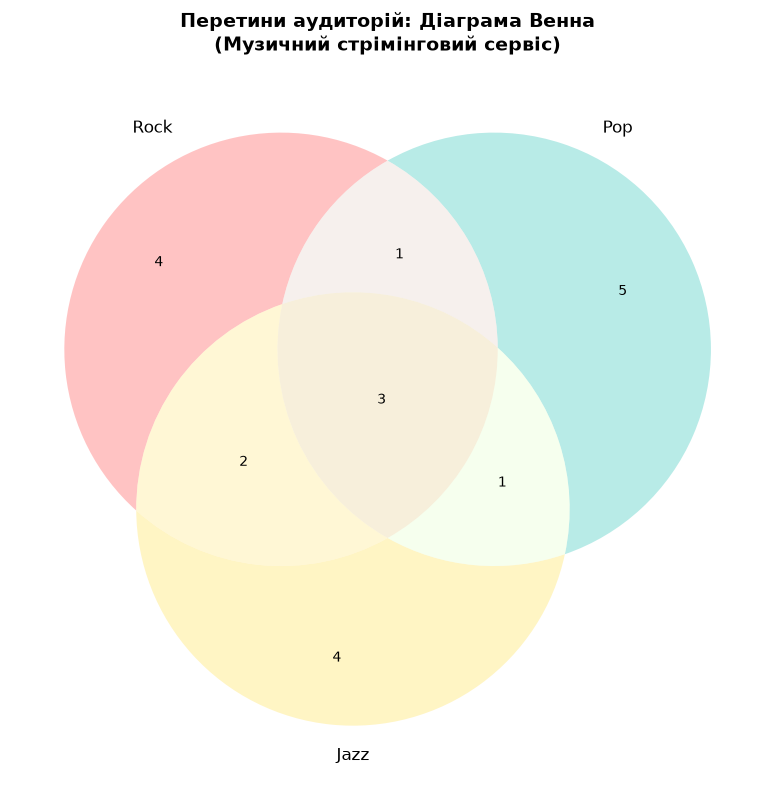

In [11]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt



# Визначаємо множини користувачів
rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}
pop_fans = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}
jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

print("=" * 60)
print("АНАЛІЗ АУДИТОРІЇ МУЗИЧНОГО СЕРВІСУ")
print("=" * 60)

# 1. Загальне охоплення — унікальні користувачі
all_users = rock_fans | pop_fans | jazz_fans
total_coverage = len(all_users)

print(f"\nЗАГАЛЬНЕ ОХОПЛЕННЯ")
print(f"   Унікальні користувачі (хоча б 1 жанр): {total_coverage}")
print(f"   ID користувачів: {sorted(all_users)}")

# 2. "Всеїдні меломани" — слухали ВСІ три жанри
omnivores = rock_fans & pop_fans & jazz_fans
print(f"\n'ВСЕЇДНІ МЕЛОМАНИ' (слухали всі 3 жанри)")
print(f"   Кількість: {len(omnivores)}")
print(f"   ID користувачів: {sorted(omnivores)}")

# 3. "Чисті рокери" — рок, але НЕ поп і НЕ джаз
pure_rock = rock_fans - pop_fans - jazz_fans
print(f"\n'ЧИСТІ РОКЕРИ' (рок, але не поп і не джаз)")
print(f"   Кількість: {len(pure_rock)}")
print(f"   ID користувачів: {sorted(pure_rock)}")

# 4. Користувачі, які слухали РІВНО два жанри
# Знаходимо перетини двох жанрів, але виключаємо тих, хто слухав усі три
rock_and_pop_only = (rock_fans & pop_fans) - jazz_fans
rock_and_jazz_only = (rock_fans & jazz_fans) - pop_fans
pop_and_jazz_only = (pop_fans & jazz_fans) - rock_fans

exactly_two = rock_and_pop_only | rock_and_jazz_only | pop_and_jazz_only

print(f"\nКОРИСТУВАЧІ З РІВНО 2 ЖАНРАМИ")
print(f"   Загальна кількість: {len(exactly_two)}")
print(f"\n   • Рок + Поп (без джазу): {sorted(rock_and_pop_only)}")
print(f"   • Рок + Джаз (без попу): {sorted(rock_and_jazz_only)}")
print(f"   • Поп + Джаз (без року): {sorted(pop_and_jazz_only)}")

# Додаткова статистика
print(f"\nДОДАТКОВА СТАТИСТИКА")
print(f"   Користувачі, які слухали рок: {len(rock_fans)}")
print(f"   Користувачі, які слухали поп: {len(pop_fans)}")
print(f"   Користувачі, які слухали джаз: {len(jazz_fans)}")

# 6. Діаграма Венна

plt.figure(figsize=(10, 8))
venn3((rock_fans, pop_fans, jazz_fans),
    set_labels=('Rock', 'Pop', 'Jazz'),  # Без емодзі
    set_colors=('#FF6B6B', '#4ECDC4', '#FFE66D'))

# Налаштування
plt.title('Перетини аудиторій: Діаграма Венна\n(Музичний стрімінговий сервіс)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('venn_diagram.png', dpi=300, bbox_inches='tight')
print(f"\nДіаграма Венна збережена як 'venn_diagram.png'")
plt.show()

print("\n" + "=" * 60)


# Задача 2. Конфігуратор доступу до системи


### Умова

Ви розробляєте модуль авторизації (RBAC — Role-Based Access Control) для корпоративного порталу. Доступ до різних секцій сайту визначається комбінацією п'яти параметрів користувача. Вам потрібно змоделювати цю логіку та перевірити всі можливі сценарії.

**Вхідні параметри користувача (булеві змінні):**

1. `is_employee` — чи є співробітником компанії
2. `is_verified` — чи пройшов верифікацію пошти
3. `is_premium` — чи має преміум-підписку
4. `is_admin` — чи є адміністратором
5. `is_banned` — чи заблокований акаунт

Правила доступу до секцій:

Система має 4 рівні доступу. Доступ надається (True), якщо виконується логічна умова:

- **Base (Базовий):** Користувач є співробітником **ТА** верифікований **ТА НЕ** заблокований.
- **Premium (Преміум):** (Користувач є співробітником **АБО** має преміум) **ТА** верифікований **ТА НЕ** заблокований.
- **Admin (Адмін-панель):** Користувач є адміністратором **ТА** верифікований **ТА НЕ** заблокований.
- **Secret (Секретні матеріали):** (Користувач є адміністратором **АБО** (є співробітником **ТА** має преміум)) **ТА** верифікований **ТА НЕ** заблокований.

Напишіть програму на Python, яка виконує наступні кроки:

1. Реалізуйте функцію:Python
    
    ```python
    def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
        # Ваш код тут
        pass
    ```
    
    Функція повинна повертати словник вигляду `{'Base': ..., 'Premium': ..., 'Admin': ..., 'Secret': ...}`, де значення — це `True` або `False`.
    
2. Згенеруйте **Таблицю істинності** для всіх 32 можливих комбінацій параметрів ($2^5 = 32$). *Підказка:* Використовуйте `itertools.product([True, False], repeat=5)` для генерації вхідних даних.
3. Виведіть таблицю у читабельному форматі (заголовок стовпчиків та рядки значень 0/1). Перші 5 стовпчиків це вхідні параметри користувача, а останні 4 це чи є доступ до відповідного рівня.
    
    ```python
    Emp   Ver   Prem  Adm   Ban   | Base  Prem  Adm   Secr
    -----------------------------------------------------------------
    1     1     1     1     1     | 0     0     0     0    
    1     1     1     1     0     | 1     1     1     1    
    1     1     1     0     1     | 0     0     0     0    
    # і далі всього 32 рядка
    ```
    
4. Проаналізуйте результати та дайте відповіді на питання (в програмі чи текстом):
    - У скількох випадках користувач має повний доступ (до всіх 4 секцій одночасно)?
    - Чи існує комбінація, де користувач має доступ до **Premium**, але **не має** доступу до **Base**? Якщо так, виведіть параметри цієї комбінації та поясніть, чому так сталося.

 💻 Програмний розвʼязок

In [18]:
import itertools
from tabulate import tabulate

def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    """
    Перевіряє доступ користувача до різних рівнів системи.

    Args:
        is_employee (bool): Чи є співробітником
        is_verified (bool): Чи верифікований
        is_premium (bool): Чи має преміум
        is_admin (bool): Чи є адміністратором
        is_banned (bool): Чи заблокований

    Returns:
        dict: Словник доступу до різних рівнів
    """

    # Базовий рівень: співробітник ТА верифікований ТА НЕ заблокований
    base_access = is_employee and is_verified and not is_banned

    # Преміум: (співробітник АБО преміум) ТА верифікований ТА НЕ заблокований
    premium_access = (is_employee or is_premium) and is_verified and not is_banned

    # Адмін-панель: адміністратор ТА верифікований ТА НЕ заблокований
    admin_access = is_admin and is_verified and not is_banned

    # Секретні матеріали: (адміністратор АБО (співробітник ТА преміум)) ТА верифікований ТА НЕ заблокований
    secret_access = (is_admin or (is_employee and is_premium)) and is_verified and not is_banned

    return {
        'Base': base_access,
        'Premium': premium_access,
        'Admin': admin_access,
        'Secret': secret_access
    }


# Генеруємо всі 32 комбінації
print("=" * 80)
print("ТАБЛИЦЯ ІСТИННОСТІ RBAC СИСТЕМИ (Всі 32 комбінації)")
print("=" * 80)

# Підготовка даних для таблиці
table_data = []
full_access_count = 0
premium_without_base = []

# Параметри для заголовка
params = ['Emp', 'Ver', 'Prem', 'Adm', 'Ban']
access_levels = ['Base', 'Premium', 'Admin', 'Secret']  # ✅ Повні назви
headers = params + ['|'] + access_levels

for combination in itertools.product([True, False], repeat=5):
    is_employee, is_verified, is_premium, is_admin, is_banned = combination

    # Отримуємо результати доступу
    access = check_access(is_employee, is_verified, is_premium, is_admin, is_banned)

    # Конвертуємо в 0/1 для таблиці
    row = [int(val) for val in combination] + ['|'] + [int(access[level]) for level in access_levels]
    table_data.append(row)

    # Аналізуємо: чи є повний доступ до всіх секцій?
    if all(access.values()):
        full_access_count += 1

    # Аналізуємо: Premium без Base
    if access['Premium'] and not access['Base']:
        premium_without_base.append({
            'combination': combination,
            'is_employee': is_employee,
            'is_verified': is_verified,
            'is_premium': is_premium,
            'is_admin': is_admin,
            'is_banned': is_banned,
            'access': access
        })

# Виводимо таблицю
print(tabulate(table_data, headers=headers, tablefmt='grid', showindex=True))

# ==================== АНАЛІЗ РЕЗУЛЬТАТІВ ====================
print("\n" + "=" * 80)
print("АНАЛІЗ РЕЗУЛЬТАТІВ")
print("=" * 80)

print(f"\nПИТАННЯ 1: У скількох випадках користувач має ПОВНИЙ доступ?")
print(f"ВІДПОВІДЬ: {full_access_count} випадків(-и)")

if full_access_count > 0:
    print(f"\n   Деталі повного доступу:")
    case_num = 1
    for combination in itertools.product([True, False], repeat=5):
        is_employee, is_verified, is_premium, is_admin, is_banned = combination
        access = check_access(is_employee, is_verified, is_premium, is_admin, is_banned)

        if all(access.values()):
            print(f"\n   Комбінація #{case_num}:")
            print(f"      • Співробітник: {is_employee}")
            print(f"      • Верифікований: {is_verified}")
            print(f"      • Преміум: {is_premium}")
            print(f"      • Адміністратор: {is_admin}")
            print(f"      • Заблокований: {is_banned}")
            case_num += 1

print(f"\nПИТАННЯ 2: Чи існує комбінація з доступом до Premium, але БЕЗ Base?")

if premium_without_base:
    print(f"ТАК, існує {len(premium_without_base)} така комбінація(-ї):")

    for i, case in enumerate(premium_without_base, 1):
        print(f"\n   Комбінація #{i}:")
        print(f"      • Співробітник: {case['is_employee']}")
        print(f"      • Верифікований: {case['is_verified']}")
        print(f"      • Преміум: {case['is_premium']}")
        print(f"      • Адміністратор: {case['is_admin']}")
        print(f"      • Заблокований: {case['is_banned']}")

        print(f"\n   Доступ:")
        for level, has_access in case['access'].items():
            status = "✓ Є доступ" if has_access else "✗ Немає доступу"
            print(f"      • {level}: {status}")

        print(f"\n   ПОЯСНЕННЯ:")
        print(f"      Користувач {'НЕ ' if not case['is_employee'] else ''}є співробітником,")
        print(f"      але МАЄ преміум-підписку.")
        print(f"      • Base вимагає: (Співробітник ТА Верифікований ТА НЕ заблокований)")
        print(f"        → {case['is_employee']} AND {case['is_verified']} AND {not case['is_banned']} = {case['is_employee'] and case['is_verified'] and not case['is_banned']}")
        print(f"      • Premium вимагає: ((Співробітник АБО Преміум) ТА Верифікований ТА НЕ заблокований)")
        print(f"        → ({case['is_employee']} OR {case['is_premium']}) AND {case['is_verified']} AND {not case['is_banned']} = {(case['is_employee'] or case['is_premium']) and case['is_verified'] and not case['is_banned']}")
        print(f"\n      Тому користувач з преміумом, але без статусу співробітника,")
        print(f"      може мати доступ до Premium, але НЕ до Base!")
else:
    print(f"НІ, такої комбінації не існує.")

# Додаткова статистика
print(f"\n" + "=" * 80)
print("ДОДАТКОВА СТАТИСТИКА")
print("=" * 80)

base_count = sum(1 for combination in itertools.product([True, False], repeat=5) 
                 if check_access(*combination)['Base'])
premium_count = sum(1 for combination in itertools.product([True, False], repeat=5) 
                    if check_access(*combination)['Premium'])
admin_count = sum(1 for combination in itertools.product([True, False], repeat=5) 
                  if check_access(*combination)['Admin'])
secret_count = sum(1 for combination in itertools.product([True, False], repeat=5) 
                   if check_access(*combination)['Secret'])

print(f"\nКількість комбінацій з доступом до кожного рівня:")
print(f"   • Base: {base_count}/32 ({base_count/32*100:.1f}%)")
print(f"   • Premium: {premium_count}/32 ({premium_count/32*100:.1f}%)")
print(f"   • Admin: {admin_count}/32 ({admin_count/32*100:.1f}%)")
print(f"   • Secret: {secret_count}/32 ({secret_count/32*100:.1f}%)")

print("\n" + "=" * 80)


ТАБЛИЦЯ ІСТИННОСТІ RBAC СИСТЕМИ (Всі 32 комбінації)
+----+-------+-------+--------+-------+-------+-----+--------+-----------+---------+----------+
|    |   Emp |   Ver |   Prem |   Adm |   Ban | |   |   Base |   Premium |   Admin |   Secret |
+====+=======+=======+========+=======+=======+=====+========+===========+=========+==========+
|  0 |     1 |     1 |      1 |     1 |     1 | |   |      0 |         0 |       0 |        0 |
+----+-------+-------+--------+-------+-------+-----+--------+-----------+---------+----------+
|  1 |     1 |     1 |      1 |     1 |     0 | |   |      1 |         1 |       1 |        1 |
+----+-------+-------+--------+-------+-------+-----+--------+-----------+---------+----------+
|  2 |     1 |     1 |      1 |     0 |     1 | |   |      0 |         0 |       0 |        0 |
+----+-------+-------+--------+-------+-------+-----+--------+-----------+---------+----------+
|  3 |     1 |     1 |      1 |     0 |     0 | |   |      1 |         1 |       0 |

# Задача 3. Формування "Команди мрії"

### Умова

Ви — Tech Lead нового амбітного стартапу. Ваше перше завдання — сформувати ідеальну команду для розробки MVP (Minimum Viable Product). HR-відділ надав вам списки кандидатів, які успішно пройшли технічну співбесіду.

У пулі кандидатів є:

- Back-end розробники: 8 осіб
- Front-end розробники: 6 осіб
- UI/UX Дизайнери: 4 особи

Згідно з бюджетом та архітектурою проєкту, команда має складатися рівно з **5 осіб** і мати таку структуру:

1. **2** Back-end розробники.
2. **2** Front-end розробники.
3. **1** Дизайнер.

Оскільки всі кандидати у списках кваліфіковані, порядок їх вибору не має значення (команда "Олег і Анна" — це те саме, що "Анна і Олег").

Тобто, це задача на **сполучення** (combinations). Однак, оскільки ми формуємо одну цілісну команду з різних груп, нам знадобиться **правило множення**.

Напишіть програму на Python, яка використовує модуль `math` та виконує наступні кроки:

1. Обчисліть, скількома способами можна вибрати необхідну кількість Back-end розробників.
2. Обчисліть, скількома способами можна вибрати необхідну кількість Front-end розробників.
3. Обчисліть, скількома способами можна вибрати одного дизайнера.
4. Використовуючи комбінаторне правило множення, знайдіть **загальну кількість** можливих унікальних складів команди.
5. Виведіть проміжні результати та фінальну відповідь у зрозумілому форматі.

 💻 Програмний розвʼязок

In [22]:
import math
from math import comb

print("=" * 80)
print("ФОРМУВАННЯ КОМАНДИ ДЛЯ MVP СТАРТАПУ")
print("=" * 80)

# Вхідні дані
backend_pool = 8          # Back-end розробники у пулі
frontend_pool = 6         # Front-end розробники у пулі
designers_pool = 4        # UI/UX Дизайнери у пулі

backend_needed = 2        # Потрібно Back-end розробників
frontend_needed = 2       # Потрібно Front-end розробників
designers_needed = 1      # Потрібно дизайнерів

print(f"\nВХІДНІ ДАНІ:")
print(f"   • Back-end розробників у пулі: {backend_pool}")
print(f"   • Front-end розробників у пулі: {frontend_pool}")
print(f"   • UI/UX Дизайнерів у пулі: {designers_pool}")
print(f"\n   • Потрібно Back-end розробників: {backend_needed}")
print(f"   • Потрібно Front-end розробників: {frontend_needed}")
print(f"   • Потрібно дизайнерів: {designers_needed}")

# ==================== КРОК 1: Back-end розробники ====================
print(f"\n" + "=" * 80)
print(f"КРОК 1. Вибір Back-end розробників")
print(f"=" * 80)

print(f"\nОбчислюємо C(n, k) = n! / (k! × (n-k)!)")
print(f"C({backend_pool}, {backend_needed}) = {backend_pool}! / ({backend_needed}! × {backend_pool - backend_needed}!)")

backend_combinations = comb(backend_pool, backend_needed)

print(f"\nФормула:")
print(f"  C({backend_pool}, {backend_needed}) = {backend_pool}! / ({backend_needed}! × {backend_pool - backend_needed}!)")
print(f"  C({backend_pool}, {backend_needed}) = {math.factorial(backend_pool)} / ({math.factorial(backend_needed)} × {math.factorial(backend_pool - backend_needed)})")
print(f"  C({backend_pool}, {backend_needed}) = {math.factorial(backend_pool)} / ({math.factorial(backend_needed) * math.factorial(backend_pool - backend_needed)})")

print(f"\nРезультат: {backend_combinations} способів вибрати {backend_needed} Back-end розробників")

# ==================== КРОК 2: Front-end розробники ====================
print(f"\n" + "=" * 80)
print(f"КРОК 2. Вибір Front-end розробників")
print(f"=" * 80)

print(f"\nОбчислюємо C(n, k) = n! / (k! × (n-k)!)")
print(f"C({frontend_pool}, {frontend_needed}) = {frontend_pool}! / ({frontend_needed}! × {frontend_pool - frontend_needed}!)")

frontend_combinations = comb(frontend_pool, frontend_needed)

print(f"\nФормула:")
print(f"  C({frontend_pool}, {frontend_needed}) = {frontend_pool}! / ({frontend_needed}! × {frontend_pool - frontend_needed}!)")
print(f"  C({frontend_pool}, {frontend_needed}) = {math.factorial(frontend_pool)} / ({math.factorial(frontend_needed)} × {math.factorial(frontend_pool - frontend_needed)})")
print(f"  C({frontend_pool}, {frontend_needed}) = {math.factorial(frontend_pool)} / ({math.factorial(frontend_needed) * math.factorial(frontend_pool - frontend_needed)})")

print(f"\nРезультат: {frontend_combinations} способів вибрати {frontend_needed} Front-end розробників")

# ==================== КРОК 3: Дизайнери ====================
print(f"\n" + "=" * 80)
print(f"КРОК 3. Вибір UI/UX дизайнера")
print(f"=" * 80)

print(f"\nОбчислюємо C(n, k) = n! / (k! × (n-k)!)")
print(f"C({designers_pool}, {designers_needed}) = {designers_pool}! / ({designers_needed}! × {designers_pool - designers_needed}!)")

designers_combinations = comb(designers_pool, designers_needed)

print(f"\nФормула:")
print(f"  C({designers_pool}, {designers_needed}) = {designers_pool}! / ({designers_needed}! × {designers_pool - designers_needed}!)")
print(f"  C({designers_pool}, {designers_needed}) = {math.factorial(designers_pool)} / ({math.factorial(designers_needed)} × {math.factorial(designers_pool - designers_needed)})")
print(f"  C({designers_pool}, {designers_needed}) = {math.factorial(designers_pool)} / ({math.factorial(designers_needed) * math.factorial(designers_pool - designers_needed)})")

print(f"\nРезультат: {designers_combinations} способів вибрати {designers_needed} дизайнера")

# ==================== КРОК 4: Правило множення ====================
print(f"\n" + "=" * 80)
print(f"КРОК 4. Комбінаторне правило множення")
print(f"=" * 80)

print(f"\nПравило множення стверджує:")
print(f"Якщо для першого вибору є m способів, а для другого — n способів,")
print(f"то для обох вибірів разом існує m × n способів.")

print(f"\nУ нашому випадку:")
print(f"  Загальна кількість способів = C(Back-end) × C(Front-end) × C(Дизайнери)")
print(f"  Загальна кількість способів = {backend_combinations} × {frontend_combinations} × {designers_combinations}")

total_teams = backend_combinations * frontend_combinations * designers_combinations

print(f"  Загальна кількість способів = {total_teams}")

# ==================== КРОК 5: Фінальна відповідь ====================
print(f"\n" + "=" * 80)
print(f"ФІНАЛЬНА ВІДПОВІДЬ")
print(f"=" * 80)

print(f"\nПРОМІЖНІ РЕЗУЛЬТАТИ:")
print(f"   ✓ Back-end комбінації:    C(8, 2) = {backend_combinations}")
print(f"   ✓ Front-end комбінації:   C(6, 2) = {frontend_combinations}")
print(f"   ✓ Дизайнер комбінації:    C(4, 1) = {designers_combinations}")

print(f"\nЗАГАЛЬНА КІЛЬКІСТЬ УНІКАЛЬНИХ СКЛАДІВ КОМАНДИ:")
print(f"   {backend_combinations} × {frontend_combinations} × {designers_combinations} = {total_teams}")

print(f"\nРЕЗУЛЬТАТ:")
print(f"   • Можна сформувати {total_teams} різних команд")
print(f"   • Кожна команда складається з 5 осіб")
print(f"   • Структура кожної команди: 2 Back-end + 2 Front-end + 1 Дизайнер")
print(f"   • Усі команди є унікальними (різні комбінації людей)")

ФОРМУВАННЯ КОМАНДИ ДЛЯ MVP СТАРТАПУ

ВХІДНІ ДАНІ:
   • Back-end розробників у пулі: 8
   • Front-end розробників у пулі: 6
   • UI/UX Дизайнерів у пулі: 4

   • Потрібно Back-end розробників: 2
   • Потрібно Front-end розробників: 2
   • Потрібно дизайнерів: 1

КРОК 1. Вибір Back-end розробників

Обчислюємо C(n, k) = n! / (k! × (n-k)!)
C(8, 2) = 8! / (2! × 6!)

Формула:
  C(8, 2) = 8! / (2! × 6!)
  C(8, 2) = 40320 / (2 × 720)
  C(8, 2) = 40320 / (1440)

Результат: 28 способів вибрати 2 Back-end розробників

КРОК 2. Вибір Front-end розробників

Обчислюємо C(n, k) = n! / (k! × (n-k)!)
C(6, 2) = 6! / (2! × 4!)

Формула:
  C(6, 2) = 6! / (2! × 4!)
  C(6, 2) = 720 / (2 × 24)
  C(6, 2) = 720 / (48)

Результат: 15 способів вибрати 2 Front-end розробників

КРОК 3. Вибір UI/UX дизайнера

Обчислюємо C(n, k) = n! / (k! × (n-k)!)
C(4, 1) = 4! / (1! × 3!)

Формула:
  C(4, 1) = 4! / (1! × 3!)
  C(4, 1) = 24 / (1 × 6)
  C(4, 1) = 24 / (6)

Результат: 4 способів вибрати 1 дизайнера

КРОК 4. Комбінатор

# Задача 4. Аналіз соціальної мережі компанії

### Умова

У невеликій IT-компанії працює 6 людей. HR-відділ хоче проаналізувати комунікацію в корпоративному месенджері: хто з ким спілкується. Вам надали дані про зв'язки між співробітниками.

Співробітники та їхні контакти (неорієнтований граф):

- **Анна** спілкується з: Богдан, Віктор, Ганна
- **Богдан** спілкується з: Анна, Віктор, Дмитро
- **Віктор** спілкується з: Анна, Богдан, Ганна, Дмитро
- **Ганна** спілкується з: Анна, Віктор, Євген
- **Дмитро** спілкується з: Богдан, Віктор, Євген
- **Євген** спілкується з: Ганна, Дмитро

Напишіть програму на Python, яка виконує наступні кроки:

1. Побудуйте **три різні представлення** цього графа:
    - Матриця суміжності (як вкладені списки)
    - Список суміжності (як словник)
    - Список ребер (як список кортежів)
2. Обчисліть **степінь кожної вершини** (кількість зв'язків кожного співробітника). Визначте, хто найбільш комунікабельний, а хто — найменш.
3. **Перевірте теорему про суму степенів:** сума степенів усіх вершин дорівнює подвоєній кількості ребер. Виведіть суму всіх степенів, кількість ребер у графі та підтвердження, що рівність виконується.

 💻 Програмний розвʼязок

АНАЛІЗ КОМУНІКАЦІЇ В КОРПОРАТИВНОМУ МЕСЕНДЖЕРІ

КРОК 1: ТРИ ПРЕДСТАВЛЕННЯ ГРАФА

Дані про контакти:
   • Анна: Богдан, Віктор, Ганна
   • Богдан: Анна, Віктор, Дмитро
   • Віктор: Анна, Богдан, Ганна, Дмитро
   • Ганна: Анна, Віктор, Євген
   • Дмитро: Богдан, Віктор, Євген
   • Євген: Ганна, Дмитро

------------------------------------------------------------------------------------------
ПРЕДСТАВЛЕННЯ 1: МАТРИЦЯ СУМІЖНОСТІ
------------------------------------------------------------------------------------------

Матриця суміжності A, де A[i][j] = 1, якщо люди спілкуються:

      Анн  Бог  Вік  Ган  Дми  Євг
    ------------------------------
Анн |   0   1   1   1   0   0
Бог |   1   0   1   0   1   0
Вік |   1   1   0   1   1   0
Ган |   1   0   1   0   0   1
Дми |   0   1   1   0   0   1
Євг |   0   0   0   1   1   0

Пояснення: 1 = спілкуються, 0 = не спілкуються
Зауважте: матриця симетрична (граф неорієнтований)

-------------------------------------------------------------------

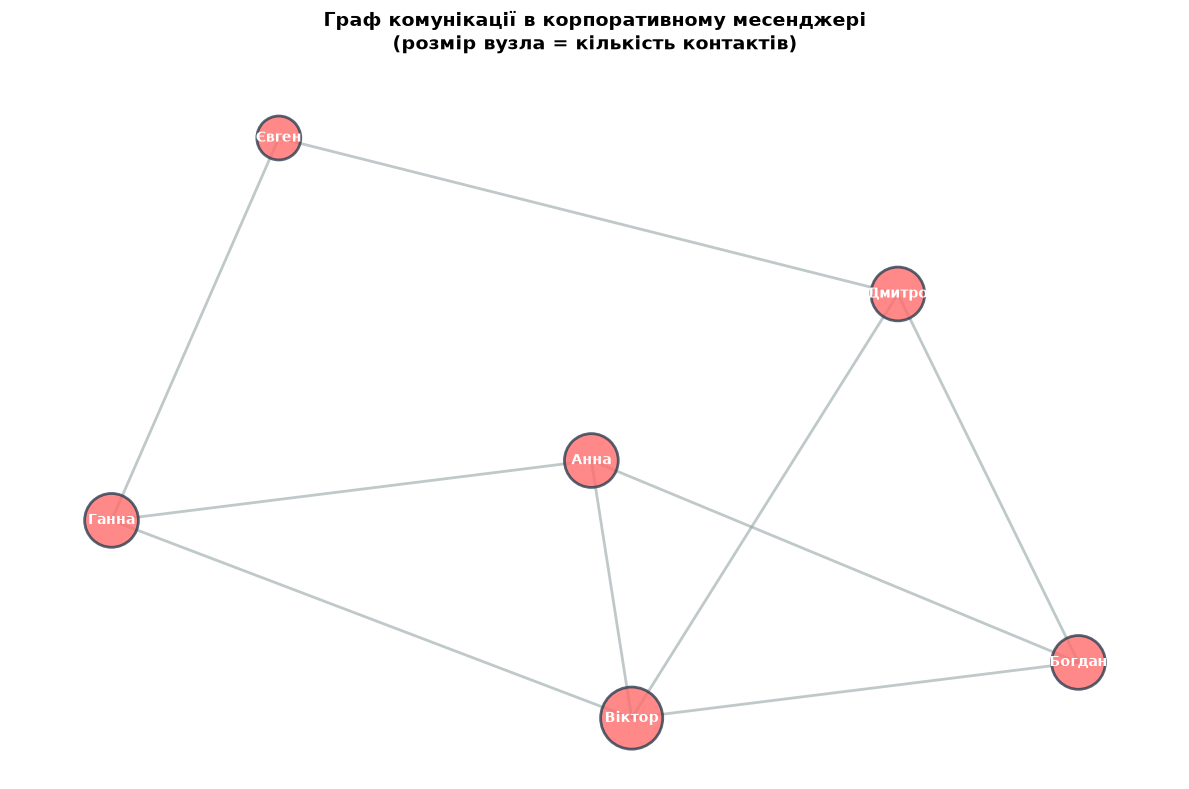

In [28]:
import itertools
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx

print("=" * 90)
print("АНАЛІЗ КОМУНІКАЦІЇ В КОРПОРАТИВНОМУ МЕСЕНДЖЕРІ")
print("=" * 90)

# ==================== КРОК 1: Побудова трьох представлень графа ====================
print(f"\n{'=' * 90}")
print(f"КРОК 1: ТРИ ПРЕДСТАВЛЕННЯ ГРАФА")
print(f"{'=' * 90}")

# Вхідні дані: список суміжності (від автора)
contacts = {
    'Анна': ['Богдан', 'Віктор', 'Ганна'],
    'Богдан': ['Анна', 'Віктор', 'Дмитро'],
    'Віктор': ['Анна', 'Богдан', 'Ганна', 'Дмитро'],
    'Ганна': ['Анна', 'Віктор', 'Євген'],
    'Дмитро': ['Богдан', 'Віктор', 'Євген'],
    'Євген': ['Ганна', 'Дмитро']
}

nodes = list(contacts.keys())
n = len(nodes)

print(f"\nДані про контакти:")
for person, contacts_list in contacts.items():
    print(f"   • {person}: {', '.join(contacts_list)}")

# ==================== ПРЕДСТАВЛЕННЯ 1: Матриця суміжності ====================
print(f"\n{'-' * 90}")
print(f"ПРЕДСТАВЛЕННЯ 1: МАТРИЦЯ СУМІЖНОСТІ")
print(f"{'-' * 90}")

# Створюємо матрицю суміжності
adjacency_matrix = [[0] * n for _ in range(n)]

# Заповнюємо матрицю
for i, person1 in enumerate(nodes):
    for j, person2 in enumerate(nodes):
        if person2 in contacts[person1]:
            adjacency_matrix[i][j] = 1

# Виводимо матрицю в красивому форматі
print(f"\nМатриця суміжності A, де A[i][j] = 1, якщо люди спілкуються:\n")

# Заголовок з іменами
header = "     " + " ".join(f"{name[:3]:>4}" for name in nodes)
print(header)
print("    " + "-" * (len(nodes) * 5))

# Рядки матриці
for i, person in enumerate(nodes):
    row_str = f"{person[:3]:>3} |"
    for j in range(n):
        row_str += f" {adjacency_matrix[i][j]:>3}"
    print(row_str)

print(f"\nПояснення: 1 = спілкуються, 0 = не спілкуються")
print(f"Зауважте: матриця симетрична (граф неорієнтований)")

# ==================== ПРЕДСТАВЛЕННЯ 2: Список суміжності ====================
print(f"\n{'-' * 90}")
print(f"ПРЕДСТАВЛЕННЯ 2: СПИСОК СУМІЖНОСТІ (СЛОВНИК)")
print(f"{'-' * 90}")

print(f"\n{contacts}")

print(f"\nДеталізовано:")
for person, contacts_list in contacts.items():
    print(f"   {person:8} → {contacts_list}")

# ==================== ПРЕДСТАВЛЕННЯ 3: Список ребер ====================
print(f"\n{'-' * 90}")
print(f"ПРЕДСТАВЛЕННЯ 3: СПИСОК РЕБЕР")
print(f"{'-' * 90}")

# Збираємо ребра (без дублювання, оскільки граф неорієнтований)
edges = set()
for person, contacts_list in contacts.items():
    for contact in contacts_list:
        # Додаємо ребро як впорядковану пару (менша назва першою)
        edge = tuple(sorted([person, contact]))
        edges.add(edge)

edges = sorted(list(edges))

print(f"\nСписок ребер (кортежів):")
print(f"{edges}")

print(f"\nДеталізовано ({len(edges)} ребер):")
for i, (person1, person2) in enumerate(edges, 1):
    print(f"   {i:2d}. ({person1:6} — {person2:6})")

# ==================== КРОК 2: Степінь вершин ====================
print(f"\n{'=' * 90}")
print(f"КРОК 2: СТЕПІНЬ ВЕРШИН (КОМУНІКАБЕЛЬНІСТЬ)")
print(f"{'=' * 90}")

# Обчислюємо степіні
degrees = {}
for person, contacts_list in contacts.items():
    degrees[person] = len(contacts_list)

# Сортуємо за степенем (спадання)
sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)

print(f"\nСтепінь кожної вершини (кількість зв'язків):\n")

max_degree = max(degrees.values())
min_degree = min(degrees.values())

for person, degree in sorted_degrees:
    bar = "█" * degree + "░" * (max_degree - degree)
    print(f"   {person:8} | {bar} | {degree} контактів")

print(f"\n🔝 Найбільш комунікабельний(і):")
max_contacts = max(degrees.values())
most_communicative = [p for p, d in degrees.items() if d == max_contacts]
for person in most_communicative:
    print(f"   • {person} ({max_contacts} контактів)")

print(f"\nНайменш комунікабельний(і):")
min_contacts = min(degrees.values())
least_communicative = [p for p, d in degrees.items() if d == min_contacts]
for person in least_communicative:
    print(f"   • {person} ({min_contacts} контактів)")

# ==================== КРОК 3: Теорема про суму степенів ====================
print(f"\n{'=' * 90}")
print(f"КРОК 3: ТЕОРЕМА ПРО СУМУ СТЕПЕНІВ")
print(f"{'=' * 90}")

sum_of_degrees = sum(degrees.values())
num_edges = len(edges)

print(f"\nТеорема: Сума степенів всіх вершин = 2 × (кількість ребер)")
print(f"\nОбчислення:")
print(f"   Сума степенів = {' + '.join(str(d) for _, d in sorted_degrees)}")
print(f"   Сума степенів = {sum_of_degrees}")

print(f"\n   Кількість ребер = {num_edges}")
print(f"   2 × (кількість ребер) = 2 × {num_edges} = {2 * num_edges}")

print(f"\nПеревірка:")
if sum_of_degrees == 2 * num_edges:
    print(f"   ✓ {sum_of_degrees} = {2 * num_edges}")
    print(f"   ✓ ТЕОРЕМА ПІДТВЕРДЖЕНА!")
else:
    print(f"   ✗ {sum_of_degrees} ≠ {2 * num_edges}")
    print(f"   ✗ Помилка в даних!")

print(f"\nРезюме:")
print(f"   • Вершин (людей): {n}")
print(f"   • Ребер (зв'язків): {num_edges}")
print(f"   • Сума всіх степенів: {sum_of_degrees}")
print(f"   • 2 × ребер = {2 * num_edges}")

# ==================== КРОК 4: Візуалізація графа ====================
print(f"\n{'=' * 90}")
print(f"КРОК 4: ВІЗУАЛІЗАЦІЯ ГРАФА")
print(f"{'=' * 90}")

# Створюємо граф за допомогою NetworkX
G = nx.Graph()

# Додаємо вершини та ребра
for person in nodes:
    G.add_node(person)

for edge in edges:
    G.add_edge(edge[0], edge[1])

# Малюємо граф
plt.figure(figsize=(12, 8))

# Використовуємо spring layout для кращої візуалізації
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Розміри вузлів залежно від степеня
node_sizes = [degrees[node] * 500 for node in G.nodes()]

# Малюємо граф
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                       node_color='#FF6B6B', alpha=0.8, edgecolors='#2C3E50', linewidths=2)

nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='#95A5A6')

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

plt.title('Граф комунікації в корпоративному месенджері\n(розмір вузла = кількість контактів)', 
          fontsize=14, fontweight='bold', pad=20)

plt.axis('off')
plt.tight_layout()
plt.savefig('communication_graph.png', dpi=300, bbox_inches='tight')
print(f"\nГраф збережений як 'communication_graph.png'")
plt.show()